In [1]:
import netCDF4
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime, timezone
import math
import cmocean
from geopy import distance
from scipy.stats import cumfreq
from scipy.interpolate import griddata
import shapefile
from functions import *


%matplotlib widget 
# Autosave every second:
%autosave 1

Autosaving every 1 seconds


In [2]:
folder = "../data/Level2B_TD/Kivuwatt/"
files = os.listdir(folder)
files.sort()

In [3]:
# fig,ax = plt.subplots(figsize=(20,10))
# for file in files:
#     nc = netCDF4.Dataset(os.path.join(folder, file), mode='r', format='NETCDF4_CLASSIC')
#     z = nc.variables["prho"][:]
#     t = nc.variables["time"][:]
#     d = nc.variables["depth_ref"][:]
#     x,y = np.meshgrid(t, d)
#     c = ax.pcolormesh(x,y,z,cmap='jet', vmin=5, vmax=25)
#     nc.close()
# ax.invert_yaxis()
# fig.colorbar(c, ax=ax)

In [4]:
coord_KivuWatt=[29.202352,-2.087932]
coord_KP1=[29.242921,-1.732214]

# 1.Single profile files (Level 2A)

In [5]:
foldername='../data/Level2A_TD/Kivuwatt/'
#filename_list=os.listdir(foldername)
files_all=os.listdir(foldername)
files_all.sort()
filename_list=files_all
#filename_list=[files_all[i] for i in [0,10,20,30,100,200,400]]
#print(filename_list)

In [6]:
# Open and store data
d=[]
rho=[]
rho_corr=[]
temp=[]
cond=[]
cond_corr=[]
temp_corr=[]
press=[]
date_all=[]
t=[];

for file in filename_list:
    nc = netCDF4.Dataset(os.path.join(foldername, file), mode='r', format='NETCDF4_CLASSIC')
    d.append(nc.variables["Depth_KW"][:]) 
    t.append(nc.variables["time"][:])
    rho.append(nc.variables["rho"][:])
    rhoval=nc.variables["rho"][:]
    rhoval[nc.variables["rho_qual"][:]==1]=np.nan
    rho_corr.append(rhoval)
    temp.append(nc.variables["Temp"][:])
    tempval=nc.variables["Temp"][:]
    tempval[nc.variables["Temp_qual"][:]==1]=np.nan
    temp_corr.append(tempval)
    cond.append(nc.variables["Cond"][:])
    condval=nc.variables["Cond"][:]
    condval[nc.variables["Cond_qual"][:]==1]=np.nan
    cond_corr.append(condval)
    press.append(nc.variables["Press"][:])
    date_prof=datetime.utcfromtimestamp(int(nc.variables["time"][0]))
    date_all.append(date_prof.strftime('%Y-%m-%d'))
    nc.close()

## 1.1. Figure pressure

Text(0.5, 0, 'Time [min]')

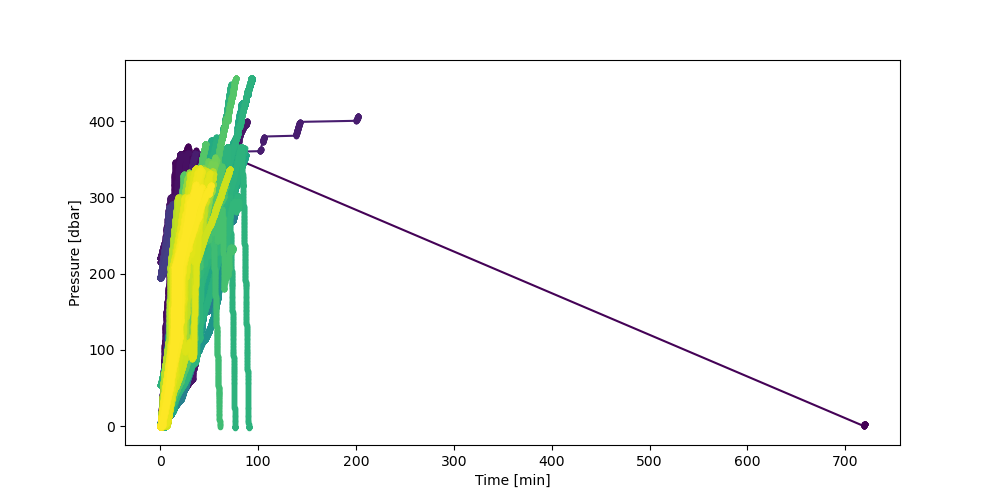

In [7]:
fig,ax=plt.subplots(figsize=(10,5))

colval=plt.get_cmap('viridis',len(filename_list))
for k in np.arange(len(filename_list)):
    ax.plot((t[k]-t[k][0])/60,press[k],color=colval(k),marker='.')
    
ax.set_ylabel('Pressure [dbar]')
ax.set_xlabel('Time [min]')
#ax.set_ylim(240,280)

## 1.2. Figure profiles

Text(0.5, 0, '$\\rho$ [kg.m$^{-3}$]')

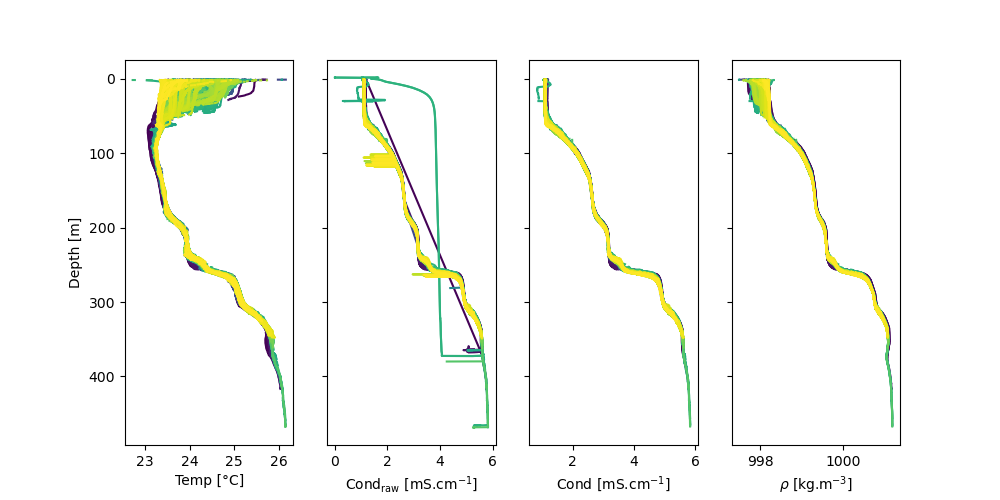

In [8]:
fig,ax=plt.subplots(1,4,figsize=(10,5),sharey=True)
cond_min=2
cond_max=3.3

colval=plt.get_cmap('viridis',len(filename_list))
for k in np.arange(len(filename_list)):
    
    ax[0].plot(temp_corr[k],d[k],color=colval(k))
    
    ax[1].plot(cond[k],d[k],color=colval(k))
    
    ax[2].plot(cond_corr[k],d[k],color=colval(k))
    #ax[2].plot(cond_corr[k][~np.isnan(cond_corr[k])],d[k][~np.isnan(cond_corr[k])],color=colval(k))
    
    ax[3].plot(rho_corr[k],d[k],color=colval(k))
# ax[0].set_ylim(240,280)
# ax[0].set_xlim(23.9,25.2)
ax[0].invert_yaxis()
ax[0].set_ylabel('Depth [m]')
ax[0].set_xlabel('Temp [°C]')
#ax[1].legend(date_all,fontsize=8,loc='upper right')
ax[1].set_xlabel('Cond$_{\\rm raw}$ [mS.cm$^{-1}$]')
#ax[1].set_xlim(3,5)
ax[2].set_xlabel('Cond [mS.cm$^{-1}$]')
ax[3].set_xlabel('$\\rho$ [kg.m$^{-3}$]')

In [27]:
fig.savefig("Figures/profiles_KW_zoom.png",dpi=400)

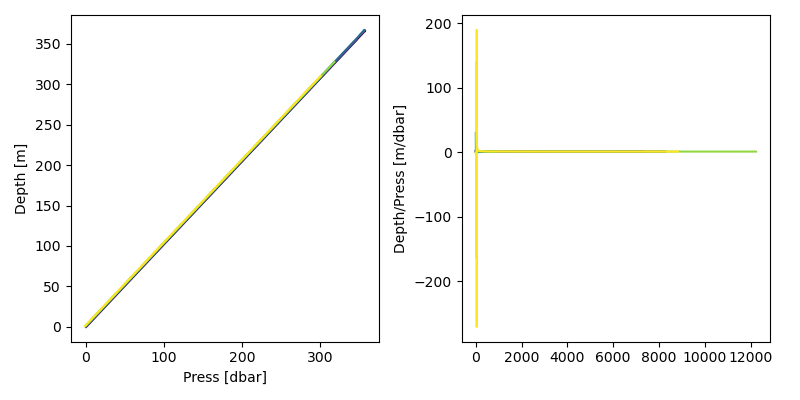

In [9]:
# Check density calculation
fig,ax=plt.subplots(1,2,figsize=(8,4))
for k in np.arange(len(filename_list)):
    ax[0].plot(press[k],d[k],color=colval(k))
    ax[1].plot(d[k]/press[k],color=colval(k))
ax[0].set_xlabel('Press [dbar]')
ax[0].set_ylabel('Depth [m]')
ax[1].set_ylabel('Depth/Press [m/dbar]')
plt.tight_layout()

# 2. Interpolated profiles (Level 2B)

In [11]:
foldername='../data/Level2B_TD/Kivuwatt/'
files_all=os.listdir(foldername)
files_all.sort()
filename_list=files_all
#filename_list=[files_all[i] for i in [0,10,20,30,100,200,400]]
#print(filename_list)

In [112]:
# Open and store data

first=True

for file in filename_list:
    nc = netCDF4.Dataset(os.path.join(foldername, file), mode='r', format='NETCDF4_CLASSIC')
    if first:
        d=nc.variables["depth_interp"][:]
        t=nc.variables["time"][:]
        rho=nc.variables["rho"][:,:]
        temp=nc.variables["Temp"][:,:]
        cond=nc.variables["Cond"][:,:]
        press=nc.variables["Press"][:,:]
        first=False
    else:
        t = np.concatenate((t, nc.variables["time"][:]), axis=0)
        rho=np.concatenate((rho,nc.variables["rho"][:,:]),axis=1)
        temp=np.concatenate((temp,nc.variables["Temp"][:,:]),axis=1)
        cond=np.concatenate((cond,nc.variables["Cond"][:,:]),axis=1)
        press=np.concatenate((press,nc.variables["Press"][:,:]),axis=1)        
    nc.close()
date_prof=np.array([datetime.utcfromtimestamp(int(t[i])) for i in np.arange(len(t))])
date_all=np.array([date_prof[i].strftime('%Y-%m-%d') for i in np.arange(len(t))])

### Figure profiles

C:\Users\dodatomy\AppData\Local\Temp\ipykernel_10756\434577029.py:1: RuntimeWarning:

More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.



Text(0.5, 0, '$\\rho$ [kg.m$^{-3}$]')

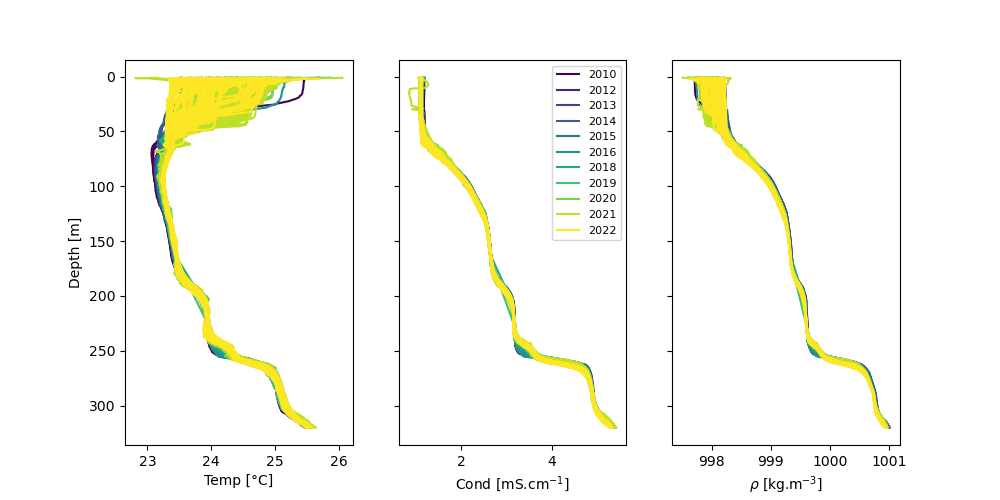

In [141]:
fig,ax=plt.subplots(1,3,figsize=(10,5),sharey=True)

yearval=np.unique([date_prof[i].year for i in np.arange(len(t))])
#colval=plt.get_cmap('viridis',len(t))
colval=plt.get_cmap('viridis',len(yearval)) # One color per year
hplots_all=[]
#indselect=np.arange(0,len(t)+1,50)
dateselect=[datetime(2010,1,1),datetime(2012,1,1),datetime(2013,1,1),datetime(2014,1,1),
             datetime(2015,1,1),datetime(2016,1,1),datetime(2018,1,1),datetime(2019,1,1),
             datetime(2020,1,1),datetime(2021,1,1),datetime(2022,1,1)]
indselect=[np.where(date_prof>dateselect[i])[0][0] for i in np.arange(len(dateselect))]
for k in np.arange(len(t)):
    kyear=np.where(yearval==date_prof[k].year)[0]
    ax[0].plot(temp[:,k],d,color=colval(kyear))
    
    hp,=ax[1].plot(cond[:,k],d,color=colval(kyear))
    hplots_all.append(hp)
    
    ax[2].plot(rho[:,k],d,color=colval(kyear))

ax[0].invert_yaxis()
ax[0].set_ylabel('Depth [m]')
ax[0].set_xlabel('Temp [°C]')
ax[1].legend(handles=[hplots_all[i] for i in  indselect],labels=[date_prof[i].year for i in  indselect],fontsize=8,loc='upper right')
ax[1].set_xlabel('Cond [mS.cm$^{-1}$]')
ax[2].set_xlabel('$\\rho$ [kg.m$^{-3}$]')